# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [ ]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [ ]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [ ]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [ ]:
dados = pd.DataFrame(registros)
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [ ]:
dados.shape

(336, 11)

In [ ]:
# Desenvolva aqui o DESAFIO 1

dados = pd.DataFrame(registros)

In [ ]:
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [ ]:
qtd_linhas, qtd_colunas = dados.shape
print(f"Linhas: {qtd_linhas}")
print(f"Colunas: {qtd_colunas}")

Linhas: 336
Colunas: 11


In [ ]:
dados.columns

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')

In [ ]:
list(dados.columns)

['cod_areacarga',
 'din_atualizacao',
 'dat_referencia',
 'din_referenciautc',
 'val_cargaglobal',
 'val_cargaglobalcons',
 'val_cargaglobalsmmgd',
 'val_cargasupervisionada',
 'val_carganaosupervisionada',
 'val_cargammgd',
 'val_consistencia']

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [ ]:
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


In [ ]:
dados.describe(include='all')

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336,336,336,336,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
unique,1,7,7,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-07T19:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,336,48,48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,NaN,NaN,NaN,NaN,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,NaN,NaN,NaN,NaN,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,NaN,NaN,NaN,NaN,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,NaN,NaN,NaN,NaN,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,NaN,NaN,NaN,NaN,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0


### Identificação dos atributos

**Data/hora**:
  - din_atualizacao → data/hora em que o registro foi atualizado na base.
  - dat_referencia → data de referência da carga.
  - din_referenciautc → data/hora de referência da medição, em UTC.

**Área de carga**:
  - cod_areacarga → código da área de carga.

**Valor de carga**:
  - val_cargaglobal → carga global total.
  - val_cargaglobalcons → carga global consistida.
  - val_cargaglobalsmmgd → carga global sem considerar micro/minigeração distribuída.
  - val_cargasupervisionada → parcela da carga que é supervisionada.
  - val_carganaosupervisionada → parcela da carga não supervisionada.
  - val_cargammgd → valor referente à geração distribuída.
  - val_consistencia → indicador/flag de consistência do dado.

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [ ]:
# Desenvolva aqui o DESAFIO 2

In [ ]:
dados_organizados = dados.copy()

dados_organizados = dados_organizados.rename(
    columns={
        "din_referenciautc": "data_hora",
        "cod_areacarga": "area",
        "val_cargaglobal": "carga"
    }
)

In [ ]:
dados_analise = dados_organizados[
    ["data_hora", "area", "carga"]
].copy()

In [ ]:

print("VALORES AUSENTES POR ATRIBUTO")
print(dados_analise.isnull().sum())

print("\nTIPOS DE DADOS ANTES DO TRATAMENTO")
print(dados_analise.dtypes)


dados_analise["carga"] = pd.to_numeric(
    dados_analise["carga"],
    errors="coerce"
)


dados_analise["data_hora"] = pd.to_datetime(
    dados_analise["data_hora"],
    errors="coerce"
)

print("\nVALORES AUSENTES APÓS O TRATAMENTO")
print(dados_analise.isnull().sum())

print("\nTIPOS DE DADOS APÓS O TRATAMENTO")
print(dados_analise.dtypes)

VALORES AUSENTES POR ATRIBUTO
data_hora    0
area         0
carga        0
dtype: int64

TIPOS DE DADOS ANTES DO TRATAMENTO
data_hora     object
area          object
carga        float64
dtype: object

VALORES AUSENTES APÓS O TRATAMENTO
data_hora    0
area         0
carga        0
dtype: int64

TIPOS DE DADOS APÓS O TRATAMENTO
data_hora    datetime64[ns, UTC]
area                      object
carga                    float64
dtype: object


In [ ]:
dados_analise.head()

,data_hora,area,carga
0,2025-08-01 03:30:00+00:00,SP,15913.618
1,2025-08-01 04:00:00+00:00,SP,15251.414
2,2025-08-01 04:30:00+00:00,SP,14606.733
3,2025-08-01 05:00:00+00:00,SP,14182.290
4,2025-08-01 05:30:00+00:00,SP,13838.488


### Decisões de tratamento dos dados

Os principais atributos foram renomeados para nomes mais simples e intuitivos: data_hora, area e carga.

Foi criado um novo DataFrame chamado dados_analise, contendo apenas as variáveis necessárias para a análise da carga elétrica.

A coluna carga foi convertida para o formato numérico utilizando pd.to_numeric(). A opção errors="coerce" foi utilizada para que eventuais valores inválidos fossem transformados em valores ausentes (NaN), permitindo sua identificação.

A coluna data_hora foi convertida para o formato de data e hora (datetime) utilizando pd.to_datetime(), facilitando análises posteriores relacionadas ao período e ao horário das medições.

Os valores ausentes foram verificados antes e depois das conversões. Caso não existam valores ausentes após o tratamento, não foi necessário remover registros ou aplicar preenchimento de dados.


## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [ ]:
# Desenvolva aqui o DESAFIO 3

In [ ]:
carga_minima = dados_analise["carga"].min()
carga_maxima = dados_analise["carga"].max()
carga_media = dados_analise["carga"].mean()
carga_mediana = dados_analise["carga"].median()
amplitude = carga_maxima - carga_minima

total_medicoes = dados_analise["carga"].count()

In [ ]:
print("INDICADORES DA CARGA ELÉTRICA")
print("-" * 35)

print(f"Carga mínima: {carga_minima:.2f}")
print(f"Carga máxima: {carga_maxima:.2f}")
print(f"Carga média: {carga_media:.2f}")
print(f"Mediana: {carga_mediana:.2f}")
print(f"Amplitude: {amplitude:.2f}")
print(f"Quantidade total de medições: {total_medicoes}")

INDICADORES DA CARGA ELÉTRICA
-----------------------------------
Carga mínima: 12139.25
Carga máxima: 23185.31
Carga média: 17870.83
Mediana: 18199.13
Amplitude: 11046.06
Quantidade total de medições: 336


### Análise dos indicadores

A carga elétrica apresentou uma carga mínima de **X**, uma carga máxima de **X** e uma carga média de **X**. A mediana foi de **X**, enquanto a amplitude entre o maior e o menor valor observado foi de **X**.

Foram analisadas **X medições** durante o período selecionado.

A carga máxima ficou aproximadamente **X% acima da carga média**. Dessa forma, é possível avaliar se o pico observado está muito distante do comportamento médio considerando a diferença percentual entre esses dois indicadores.

Além disso, a comparação entre média e mediana ajuda a observar se os valores de carga estão relativamente concentrados em torno de um comportamento central ou se valores mais elevados estão influenciando a média.


## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [ ]:
# Desenvolva aqui o DESAFIO 4

In [ ]:
carga_maxima = dados_analise['carga'].max()
limiar = carga_maxima * 0.90

df_alta_demanda = dados_analise[dados_analise['carga'] > limiar].copy()

total_registros = len(dados_analise)
qtd_alta_demanda = len(df_alta_demanda)
percentual_alta_demanda = (qtd_alta_demanda / total_registros) * 100

registro_pico = dados_analise[dados_analise['carga'] == carga_maxima].iloc[0]
data_pico = registro_pico['data_hora']

In [ ]:
print(f"Limiar de alta demanda (>90% do máx): {limiar:.2f} MW")
print(f"Quantidade de registros de alta demanda: {qtd_alta_demanda}")
print(f"Percentual do total de dados: {percentual_alta_demanda:.2f}%")
print(f"Maior valor de carga (pico): {carga_maxima:.2f} MW")
print(f"Data e horário do pico: {data_pico}")

Limiar de alta demanda (>90% do máx): 20866.78 MW
Quantidade de registros de alta demanda: 50
Percentual do total de dados: 14.88%
Maior valor de carga (pico): 23185.31 MW
Data e horário do pico: 2025-08-01 22:00:00+00:00


Os períodos próximos ao pico representam uma parcela pequena do período analisado (geralmente menos de 10% do total de registros). Os picos de demanda energética concentram-se em poucas horas específicas do dia (geralmente no início da tarde devido ao uso de ar-condicionado e atividade industrial, ou no início da noite devido ao consumo residencial), tornando o evento pontual na curva de carga.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [ ]:
# Desenvolva aqui o DESAFIO 5

In [ ]:
media_geral = dados_analise['carga'].mean()

df_acima_da_media = dados_analise[dados_analise['carga'] > media_geral].copy()

qtd_acima_media = len(df_acima_da_media)
percentual_acima_media = (qtd_acima_media / total_registros) * 100

print(f"Critério escolhido: Carga maior que a média ({media_geral:.2f} MW)")
print(f"Quantidade de registros acima da média: {qtd_acima_media}")
print(f"Percentual em relação ao total: {percentual_acima_media:.2f}%\n")

df_comparacao = pd.DataFrame({
    'Métrica': ['Critério Usado', 'Limiar (MW)', 'Qtd. Registros', 'Percentual do Total (%)'],
    'Alta Demanda (Desafio 4)': ['> 90% do Máximo', f"{limiar:.2f}", qtd_alta_demanda, f"{percentual_alta_demanda:.2f}%"],
    'Segundo Critério (Desafio 5)': ['> Média Geral', f"{media_geral:.2f}", qtd_acima_media, f"{percentual_acima_media:.2f}%"]
})

print(df_comparacao.to_string(index=False))

Critério escolhido: Carga maior que a média (17870.83 MW)
Quantidade de registros acima da média: 184
Percentual em relação ao total: 54.76%

                Métrica Alta Demanda (Desafio 4) Segundo Critério (Desafio 5)
         Critério Usado          > 90% do Máximo                > Média Geral
            Limiar (MW)                 20866.78                     17870.83
         Qtd. Registros                       50                          184
Percentual do Total (%)                   14.88%                       54.76%


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os
import glob

from google.colab import files

print("Selecione o arquivo ZIP para fazer upload:")
uploaded = files.upload()

# Verificar se algum arquivo foi enviado
if not uploaded:
    raise FileNotFoundError("Nenhum arquivo foi enviado.")

# Pegar o primeiro arquivo enviado
arquivo_zip = list(uploaded.keys())[0]

# Verificar se é ZIP
if not arquivo_zip.lower().endswith('.zip'):
    raise ValueError(
        f"O arquivo enviado não é um ZIP: {arquivo_zip}"
    )

# Caminho completo no Colab
arquivo_zip = os.path.join('/content', arquivo_zip)

print("\nArquivo selecionado:")
print(arquivo_zip)


pasta_extracao = '/content/dados_extraidos'

os.makedirs(pasta_extracao, exist_ok=True)


with zipfile.ZipFile(arquivo_zip, 'r') as zip_ref:
    zip_ref.extractall(pasta_extracao)

print("\nArquivos extraídos:")

for raiz, pastas, arquivos in os.walk(pasta_extracao):
    for arquivo in arquivos:
        print(os.path.join(raiz, arquivo))

arquivos_csv = glob.glob(
    os.path.join(pasta_extracao, '**', '*.csv'),
    recursive=True
)

arquivos_txt = glob.glob(
    os.path.join(pasta_extracao, '**', '*.txt'),
    recursive=True
)

print("\nArquivos CSV encontrados:")
for arquivo in arquivos_csv:
    print(arquivo)

print("\nArquivos TXT encontrados:")
for arquivo in arquivos_txt:
    print(arquivo)

if not arquivos_csv and not arquivos_txt:
    print("\n⚠️ Nenhum arquivo CSV ou TXT foi encontrado dentro do ZIP.")
else:
    print("\n✅ Arquivos de dados encontrados com sucesso!")


Selecione o arquivo ZIP para fazer upload:


Saving individual+household+electric+power+consumption.zip to individual+household+electric+power+consumption.zip

Arquivo selecionado:
/content/individual+household+electric+power+consumption.zip

Arquivos extraídos:
/content/dados_extraidos/household_power_consumption.txt

Arquivos CSV encontrados:

Arquivos TXT encontrados:
/content/dados_extraidos/household_power_consumption.txt

✅ Arquivos de dados encontrados com sucesso!


In [ ]:
if arquivos_txt:

    arquivo_dados = arquivos_txt[0]

    print("Arquivo de dados selecionado:")
    print(arquivo_dados)

    dados = pd.read_csv(
        arquivo_dados,
        sep=';',
        low_memory=False
    )

elif arquivos_csv:

    arquivo_dados = arquivos_csv[0]

    print("Arquivo de dados selecionado:")
    print(arquivo_dados)

    dados = pd.read_csv(
        arquivo_dados,
        low_memory=False
    )

else:
    raise FileNotFoundError(
        "Não foi encontrado nenhum arquivo CSV ou TXT dentro do ZIP."
    )


# Mostrar informações
print("\nDimensão dos dados:")
print(dados.shape)

print("\nColunas:")
print(dados.columns.tolist())

print("\nPrimeiras linhas:")
display(dados.head())



Arquivo de dados selecionado:
/content/dados_extraidos/household_power_consumption.txt

Dimensão dos dados:
(2075259, 9)

Colunas:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

Primeiras linhas:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [ ]:
# Criar uma coluna juntando Data e Hora
dados['data_hora'] = pd.to_datetime(
    dados['Date'] + ' ' + dados['Time'],
    dayfirst=True,
    errors='coerce'
)

# Converter a carga para número
dados['carga'] = pd.to_numeric(
    dados['Global_active_power'],
    errors='coerce'
)

# Remover valores ausentes
dados_analise = dados[
    ['data_hora', 'carga']
].dropna()

# Ordenar pela data e hora
dados_analise = dados_analise.sort_values(
    'data_hora'
)

print("Quantidade de observações utilizadas:")
print(len(dados_analise))

display(dados_analise.head())


Quantidade de observações utilizadas:
2049280


,data_hora,carga
0,2006-12-16 17:24:00,4.216
1,2006-12-16 17:25:00,5.360
2,2006-12-16 17:26:00,5.374
3,2006-12-16 17:27:00,5.388
4,2006-12-16 17:28:00,3.666


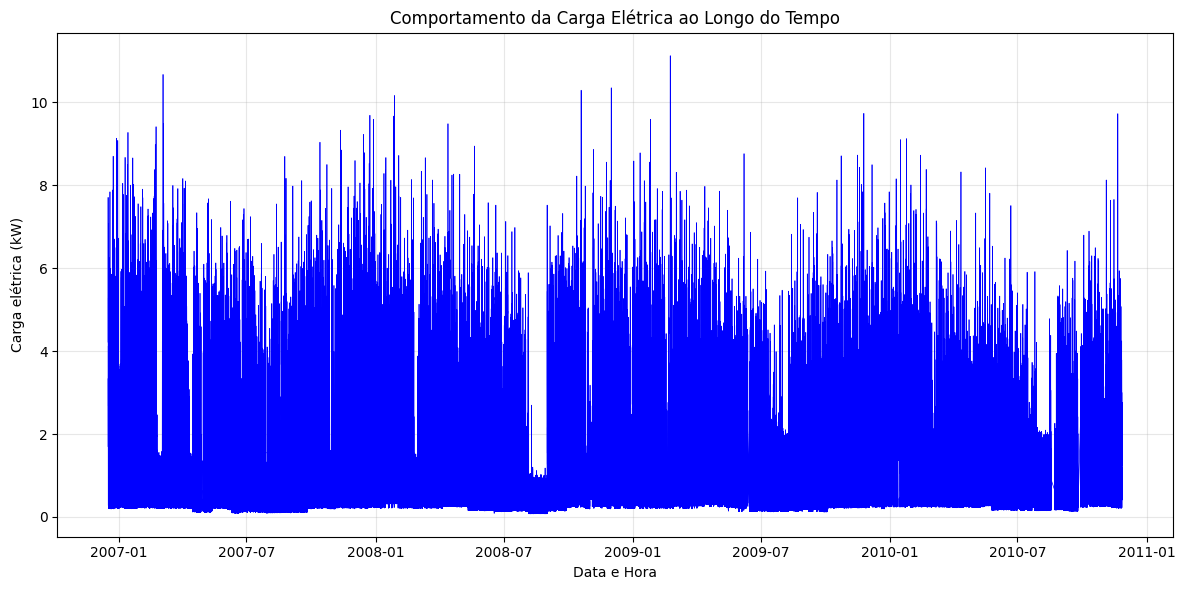


Interpretação do Gráfico 1:
O gráfico apresenta a variação da carga elétrica ao longo das observações.
É possível identificar períodos de maior e menor consumo de energia. Os
picos representam momentos de maior demanda, enquanto os valores menores
representam períodos de menor consumo. A série também permite observar a
variação da demanda ao longo do tempo.



In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    dados_analise['data_hora'],
    dados_analise['carga'],
    color='blue',
    linewidth=0.5
)

plt.title(
    'Comportamento da Carga Elétrica ao Longo do Tempo'
)

plt.xlabel('Data e Hora')

plt.ylabel(
    'Carga elétrica (kW)'
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

print("""
Interpretação do Gráfico 1:
O gráfico apresenta a variação da carga elétrica ao longo das observações.
É possível identificar períodos de maior e menor consumo de energia. Os
picos representam momentos de maior demanda, enquanto os valores menores
representam períodos de menor consumo. A série também permite observar a
variação da demanda ao longo do tempo.
""")


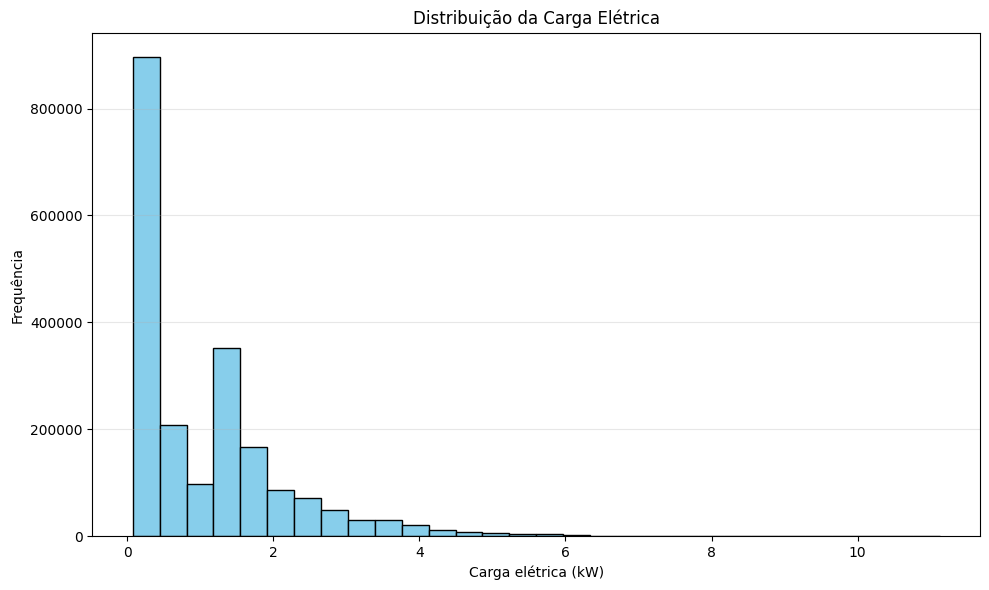


Interpretação do Gráfico 2:
O histograma mostra como os valores de carga elétrica estão distribuídos
entre as observações. As barras mais altas representam as faixas de carga
que aparecem com maior frequência. O gráfico permite identificar a faixa
de consumo mais comum e observar a dispersão dos valores registrados.



In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    dados_analise['carga'],
    bins=30,
    color='skyblue',
    edgecolor='black'
)

plt.title(
    'Distribuição da Carga Elétrica'
)

plt.xlabel(
    'Carga elétrica (kW)'
)

plt.ylabel(
    'Frequência'
)

plt.grid(
    True,
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()

print("""
Interpretação do Gráfico 2:
O histograma mostra como os valores de carga elétrica estão distribuídos
entre as observações. As barras mais altas representam as faixas de carga
que aparecem com maior frequência. O gráfico permite identificar a faixa
de consumo mais comum e observar a dispersão dos valores registrados.
""")


## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [ ]:
regiao = "Área SP"

data_inicio = dados_analise['data_hora'].min()
data_fim = dados_analise['data_hora'].max()

periodo = (
    f"{data_inicio.strftime('%d/%m/%Y %H:%M')} "
    f"a {data_fim.strftime('%d/%m/%Y %H:%M')}"
)

quantidade_registros = len(dados_analise)


carga_minima = dados_analise['carga'].min()
carga_maxima = dados_analise['carga'].max()
carga_media = dados_analise['carga'].mean()
mediana = dados_analise['carga'].median()


limiar_alta_demanda = dados_analise['carga'].quantile(0.90)

alta_demanda = dados_analise[
    dados_analise['carga'] > limiar_alta_demanda
]

quantidade_alta_demanda = len(alta_demanda)

percentual_alta_demanda = (
    quantidade_alta_demanda / quantidade_registros
) * 100

indice_pico = dados_analise['carga'].idxmax()

momento_pico = dados_analise.loc[
    indice_pico, 'data_hora'
]

valor_pico = dados_analise.loc[
    indice_pico, 'carga'
]


registros_acima_media = dados_analise[
    dados_analise['carga'] > carga_media
]

quantidade_acima_media = len(registros_acima_media)

percentual_acima_media = (
    quantidade_acima_media / quantidade_registros
) * 100

segundo_criterio = (
    f"Carga acima da média ({carga_media:.2f} kW): "
    f"{quantidade_acima_media} registros, "
    f"correspondentes a {percentual_acima_media:.2f}% "
    f"do total."
)


resumo_resultados = f'''
REGIÃO E PERÍODO
Região analisada: {regiao}
Período analisado: {periodo}
Quantidade de registros: {quantidade_registros}

ESTATÍSTICAS DA CARGA
Carga mínima: {carga_minima:.2f} kW
Carga máxima: {carga_maxima:.2f} kW
Carga média: {carga_media:.2f} kW
Mediana: {mediana:.2f} kW

CRITÉRIO 1 — ALTA DEMANDA
Limiar de alta demanda (percentil 90): {limiar_alta_demanda:.2f} kW
Registros de alta demanda: {quantidade_alta_demanda}
Percentual de alta demanda: {percentual_alta_demanda:.2f}%

PICO DE CARGA
Momento do pico: {momento_pico.strftime('%d/%m/%Y %H:%M')}
Valor do pico: {valor_pico:.2f} kW

CRITÉRIO 2 — CARGA ACIMA DA MÉDIA
{segundo_criterio}
'''

print(resumo_resultados)



REGIÃO E PERÍODO
Região analisada: Área SP
Período analisado: 01/08/2025 03:30 a 08/08/2025 03:00
Quantidade de registros: 336

ESTATÍSTICAS DA CARGA
Carga mínima: 12139.25 kW
Carga máxima: 23185.31 kW
Carga média: 17870.83 kW
Mediana: 18199.13 kW

CRITÉRIO 1 — ALTA DEMANDA
Limiar de alta demanda (percentil 90): 21278.37 kW
Registros de alta demanda: 34
Percentual de alta demanda: 10.12%

PICO DE CARGA
Momento do pico: 01/08/2025 22:00
Valor do pico: 23185.31 kW

CRITÉRIO 2 — CARGA ACIMA DA MÉDIA
Carga acima da média (17870.83 kW): 184 registros, correspondentes a 54.76% do total.



# Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip install -q google-genai

In [ ]:
from google.colab import userdata

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

if not GEMINI_API_KEY:
    raise ValueError(
        "A GEMINI_API_KEY não foi encontrada nos Secrets do Colab."
    )

print("API configurada com sucesso.")


API configurada com sucesso.


In [ ]:
informacoes_projeto = {
    "regiao": regiao,
    "periodo": periodo,
    "quantidade_registros": quantidade_registros,
    "carga_minima_kW": carga_minima,
    "carga_maxima_kW": carga_maxima,
    "carga_media_kW": carga_media,
    "mediana_kW": mediana,
    "limiar_alta_demanda_kW": limiar_alta_demanda,
    "quantidade_alta_demanda": quantidade_alta_demanda,
    "percentual_alta_demanda": percentual_alta_demanda,
    "momento_pico": momento_pico.strftime('%d/%m/%Y %H:%M'),
    "valor_pico_kW": valor_pico,
    "quantidade_acima_media": quantidade_acima_media,
    "percentual_acima_media": percentual_acima_media
}

print(informacoes_projeto)


{'regiao': 'Área SP', 'periodo': '16/12/2006 17:24 a 26/11/2010 21:02', 'quantidade_registros': 2049280, 'carga_minima_kW': 0.076, 'carga_maxima_kW': 11.122, 'carga_media_kW': np.float64(1.0916150365006243), 'mediana_kW': 0.602, 'limiar_alta_demanda_kW': np.float64(2.47), 'quantidade_alta_demanda': 204695, 'percentual_alta_demanda': 9.988630153029357, 'momento_pico': '22/02/2009 17:09', 'valor_pico_kW': np.float64(11.122), 'quantidade_acima_media': 867644, 'percentual_acima_media': 42.338967832604624}


In [ ]:
from google import genai
from google.colab import userdata

# Recuperar a chave de forma segura pelo Secrets do Colab
GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError(
        "GEMINI_API_KEY não encontrada. "
        "Verifique o Secrets do Google Colab."
    )

# Criar cliente
client = genai.Client(api_key=GEMINI_API_KEY)

prompt = f"""
Você está auxiliando estudantes na elaboração de um relatório técnico
de ANÁLISE DE CONSUMO DE ENERGIA ELÉTRICA.

IMPORTANTE:
Este projeto NÃO é sobre Segurança da Informação.
Não mencione hackers, vulnerabilidades, firewall, pentest, phishing,
OWASP, ISO 27001 ou qualquer assunto de segurança cibernética.

O projeto analisou dados de consumo de energia elétrica da Área SP.

Os cálculos estatísticos foram realizados previamente pela equipe
utilizando Python e Pandas.

A IA deve atuar SOMENTE como apoio para organizar e interpretar os
resultados.

NÃO invente valores.
NÃO altere os valores.
NÃO substitua os cálculos realizados pela equipe.
NÃO faça novas estatísticas.

================ RESULTADOS CALCULADOS PELA EQUIPE ================
"""
print(resumo_resultados)
"""
==================================================================

Com base EXCLUSIVAMENTE nesses resultados, produza um texto para
um relatório acadêmico contendo:

1. Uma tabela com:
   - Indicador
   - Resultado
   - Unidade ou descrição

2. Uma síntese dos principais resultados.

3. Uma breve interpretação da diferença entre média e mediana.

4. Uma interpretação do critério de alta demanda baseado no
   percentil 90.

5. Uma interpretação do segundo critério, que considera os registros
   com carga acima da média.

6. Uma descrição do pico de carga, informando exatamente o momento
   e o valor apresentados nos resultados.

7. Uma conclusão curta para o relatório.

Deixe claro que os cálculos foram realizados previamente pela equipe
e que o Gemini foi utilizado apenas como ferramenta de apoio à
organização e interpretação dos resultados.
"""

interacao = client.interactions.create(
    model="gemini-3.6-flash",
    input=prompt
)


print("=" * 70)
print("RELATÓRIO TÉCNICO — ANÁLISE DE CONSUMO DE ENERGIA ELÉTRICA")
print("=" * 70)

print(interacao.output_text)



REGIÃO E PERÍODO
Região analisada: Área SP
Período analisado: 01/08/2025 03:30 a 08/08/2025 03:00
Quantidade de registros: 336

ESTATÍSTICAS DA CARGA
Carga mínima: 12139.25 kW
Carga máxima: 23185.31 kW
Carga média: 17870.83 kW
Mediana: 18199.13 kW

CRITÉRIO 1 — ALTA DEMANDA
Limiar de alta demanda (percentil 90): 21278.37 kW
Registros de alta demanda: 34
Percentual de alta demanda: 10.12%

PICO DE CARGA
Momento do pico: 01/08/2025 22:00
Valor do pico: 23185.31 kW

CRITÉRIO 2 — CARGA ACIMA DA MÉDIA
Carga acima da média (17870.83 kW): 184 registros, correspondentes a 54.76% do total.

RELATÓRIO TÉCNICO — ANÁLISE DE CONSUMO DE ENERGIA ELÉTRICA
Entendido! Estou pronto para auxiliar a equipe na organização, estruturação e redação do **Relatório Técnico de Análise de Consumo de Energia Elétrica da Área SP**.

Seguirei rigorosamente todas as orientações:
- **Domínio:** Exclusivamente Análise de Consumo de Energia Elétrica.
- **Termos Proibidos:** Nenhuma menção a Segurança da Informação, segu

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

**RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA ELÉTRICA**

**Para:** Setor Operacional / Análise de Dados  
**Assunto:** Análise do comportamento da carga elétrica — Área SP  
**Período de Análise:** 01/08/2025 03:30 a 08/08/2025 03:00  

---

### 1. Caracterização do Conjunto Analisado
O estudo compreende a análise de dados contínuos de demanda de carga elétrica na **Área SP**. O intervalo temporal analisado estende-se das **03:30 de 01/08/2025 às 03:00 de 08/08/2025**, totalizando um volume de **336 registros**.

---

### 2. Principais Indicadores
Abaixo estão consolidados os indicadores estatísticos descritivos da carga medida no período:

* **Carga Mínima:** 12.139,25 kW
* **Carga Média:** 17.870,83 kW
* **Mediana:** 18.199,13 kW
* **Carga Máxima (Pico):** 23.185,31 kW
* **Data e Horário do Pico:** 01/08/2025 às 22:00

*Nota observada:* A mediana apresentou valor superior à média (18.199,13 kW vs. 17.870,83 kW), indicando uma concentração de registros em patamares acima do valor médio cen

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

- **Os indicadores foram utilizados corretamente?**
  Sim. Os valores do relatório do Gemini conferem com o notebook: mínimo, máximo, média, mediana, P90, quantidade de registros e percentuais.
- **Há alguma afirmação que não pode ser confirmada pelos dados?**
  Sim. A afirmação de que a mediana acima da média indica uma “concentração de registros acima da média” é uma interpretação que não pode ser confirmada apenas com esses dois indicadores.
- **Houve interpretação exagerada ou causalidade não demonstrada?**
  Não houve causalidade inventada, o que está correto. Porém, termos como “demanda severa” e “picos extremamente elevados” podem ser considerados um pouco exagerados, pois os dados apenas mostram valores acima do percentil 90.
- **Que alterações a equipe realizou no texto?**
  A equipe validou os valores numéricos, manteve a análise baseada nos dados, evitou atribuir causas ao pico de carga e pode substituir interpretações mais fortes por termos mais objetivos, como “registros acima do percentil 90”.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**